In [1]:
pip install pytrends matplotlib seaborn plotly pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
pytrends = TrendReq(hl='en-US', tz=360)
keyword="cloud computing"

In [4]:
pytrends.build_payload([keyword], cat=0, timeframe='today 12-m', geo='', gprop="")


In [5]:
region_data=pytrends.interest_by_region()
region_data = region_data.sort_values(by=keyword, ascending=False).head(15)

C:\Users\Palak\AppData\Local\Temp\ipykernel_7100\1215987049.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_data[keyword],y=region_data.index,palette='viridis_d')


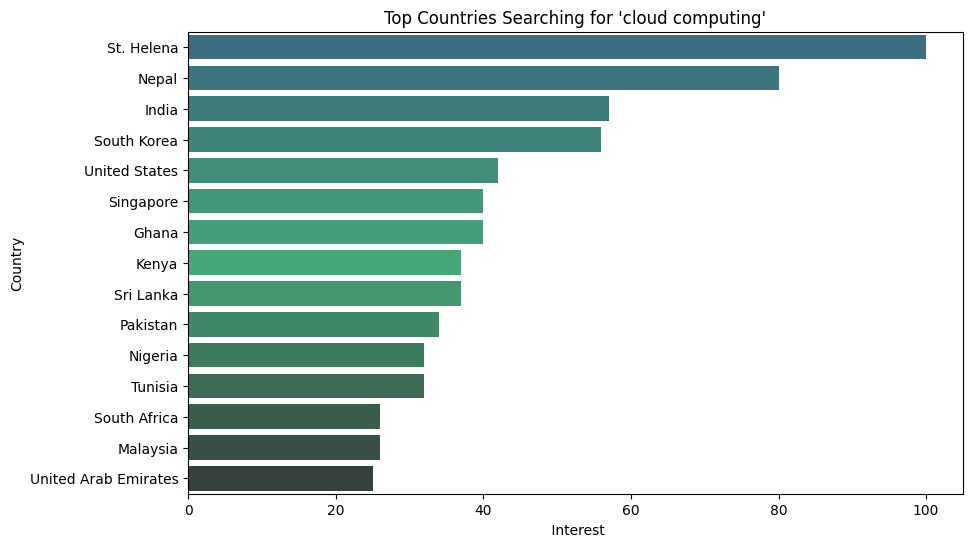

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(x=region_data[keyword],y=region_data.index,palette='viridis_d')
plt.title(f"Top Countries Searching for '{keyword}'")
plt.xlabel(' Interest')
plt.ylabel('Country')
plt.show()


In [7]:
pip install ipython


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
region_data = region_data.reset_index()
fig = px.choropleth(region_data, locations='geoName', locationmode='country names',
                    color=keyword, title=f"Search Interest for '{keyword}' by Country",
                    color_continuous_scale='Viridis')
fig.show(renderer="browser")

C:\Users\Palak\AppData\Local\Temp\ipykernel_7100\1118819275.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(region_data, locations='geoName', locationmode='country names',


In [9]:
time_df=pytrends.interest_over_time()

c:\Users\Palak\AppData\Local\Programs\Python\Python310\lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


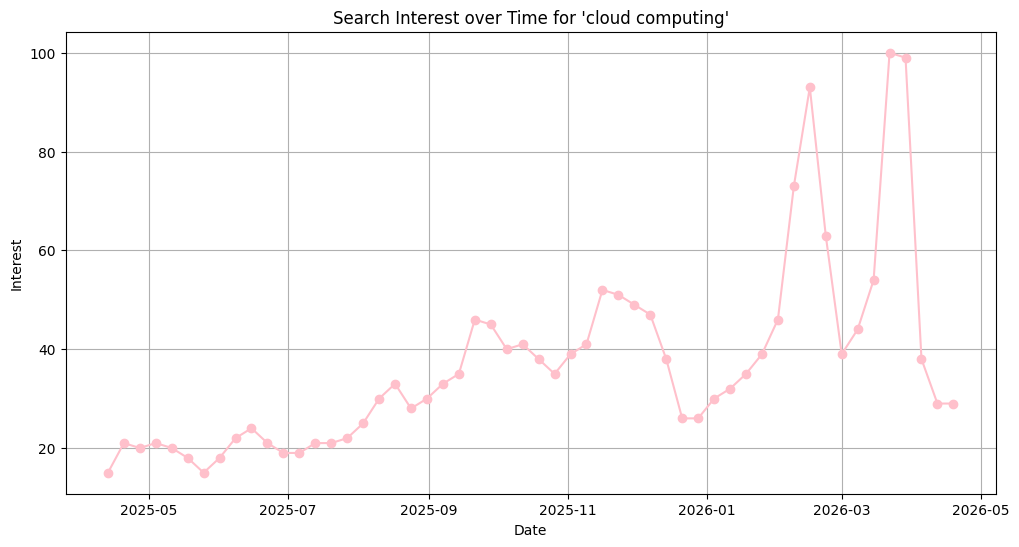

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(time_df.index, time_df[keyword], marker='o', color='pink')
plt.title(f"Search Interest over Time for '{keyword}'")
plt.xlabel('Date')
plt.ylabel('Interest')
plt.grid(True)
plt.show()

In [11]:
kw_list = ["cloud computing", "data science", "machine learning"]
pytrends.build_payload(kw_list, cat=0, timeframe='today 12-m', geo='', gprop="")


c:\Users\Palak\AppData\Local\Programs\Python\Python310\lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


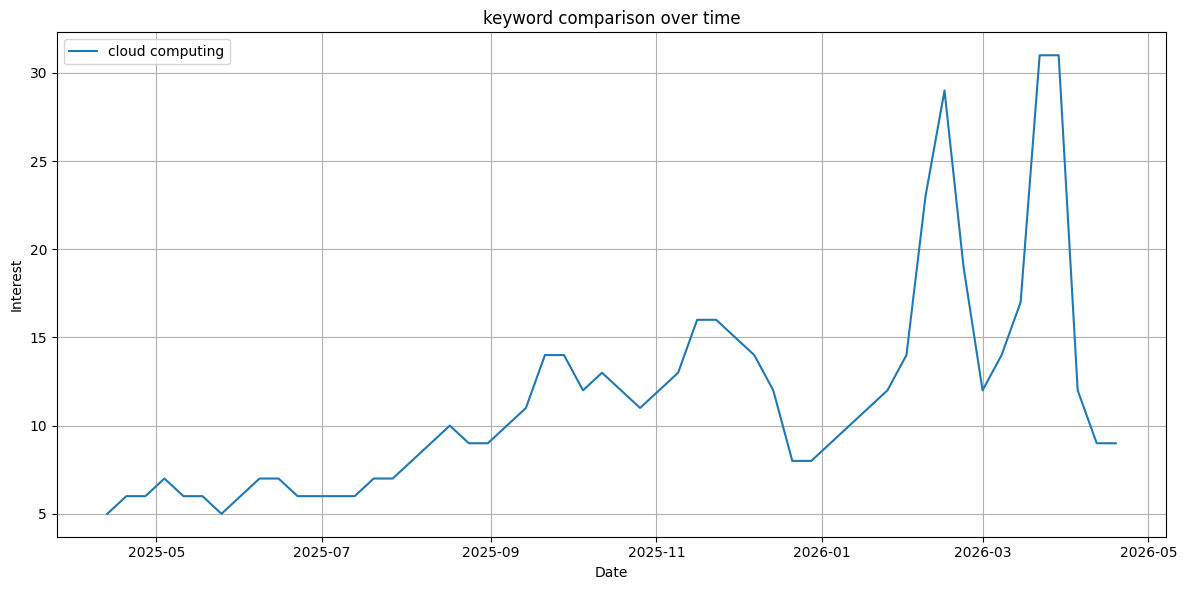

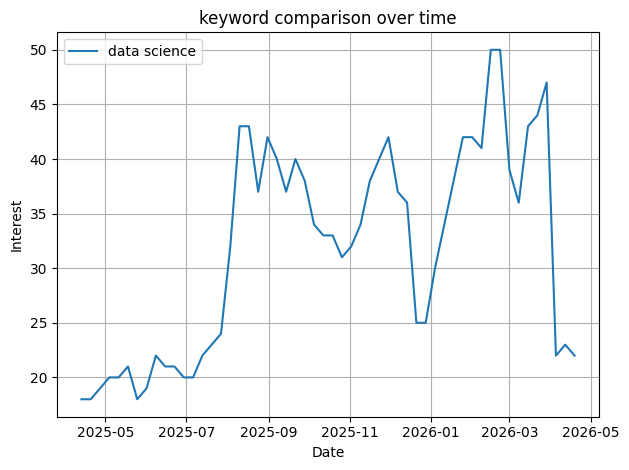

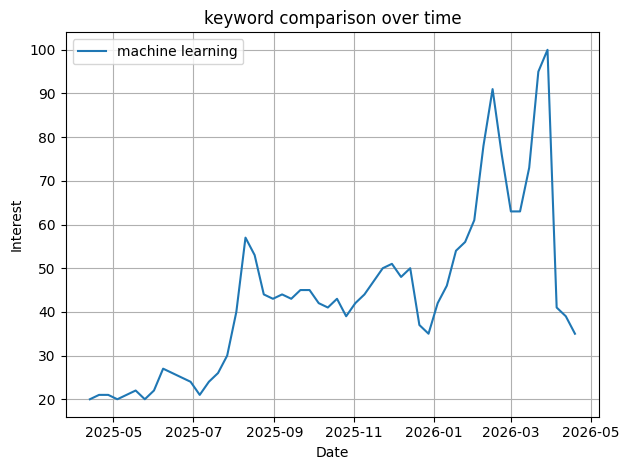

In [12]:
compare_df = pytrends.interest_over_time()
plt.figure(figsize=(12, 6))
for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label=kw)
    plt.title("keyword comparison over time")
    plt.xlabel('Date')
    plt.ylabel('Interest')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    